# HypeGuard — Notebook 03: Model Validation
**Pre-requisite:** Run `02_Model_Training.ipynb` first — `.pkl` files must exist.

**What this notebook does:**
1. Loads trained models from `../backend/models/`
2. Runs end-to-end prediction on 5 known tickers
3. Checks GME/AMC score HIGH, NVDA/AAPL/MSFT score LOW
4. Produces the final validation chart for your report
5. Simulates exactly what the FastAPI `/analyze` endpoint will do

In [6]:
# ═══════════════════════════════════════════════════════════
# CELL 1 — LOAD MODELS + DEFINE PREDICTION FUNCTION
# ═══════════════════════════════════════════════════════════
import sys, pickle, warnings
sys.path.append('../backend/src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scraper  import collect_all
from features import build_feature_vector

# ── Plot style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':'#0f0f0f','axes.facecolor':'#1a1a1a',
    'text.color':'white','axes.labelcolor':'white',
    'xtick.color':'white','ytick.color':'white',
    'axes.edgecolor':'#444','grid.color':'#333',
    'font.family':'monospace',
})
RED=   '#ef4444'; GREEN='#22c55e'; AMBER='#f59e0b'
ORANGE='#f97316'; GRAY= '#6b7280'; BLUE= '#3b82f6'

# ── Load models ────────────────────────────────────────────
print('Loading models...')

with open('../backend/models/random_forest.pkl', 'rb') as f:
    rf_bundle = pickle.load(f)

with open('../backend/models/isolation_forest.pkl', 'rb') as f:
    iso_bundle = pickle.load(f)

rf             = rf_bundle['model']
FEATURES_FINAL = rf_bundle['feature_order']
LABEL_MAP      = rf_bundle['label_map']
LABEL_MAP_INV  = rf_bundle['label_map_inv']

iso    = iso_bundle['model']
scaler = iso_bundle['scaler']

# Find HYPE class index in rf.classes_
hype_class_idx = list(rf.classes_).index(LABEL_MAP['HYPE']) \
    if LABEL_MAP['HYPE'] in rf.classes_ else None

print(f'  ✓ Random Forest loaded   | features={len(FEATURES_FINAL)} | classes={rf.classes_.tolist()}')
print(f'  ✓ Isolation Forest loaded | scaler fitted')
print(f'  ✓ HYPE class index in predict_proba: {hype_class_idx}')


# ── End-to-end prediction function ─────────────────────────
def predict_ticker(ticker: str, verbose: bool = True) -> dict:
    """
    Replicates exactly what api.py -> model.py does:
      collect_all → build_feature_vector → IsoForest → RandomForest → hype_score

    Returns a dict with all scores + reasoning.
    """
    if verbose:
        print(f'  Analyzing {ticker}...')

    # Step 1: Data collection
    raw = collect_all(ticker, days=60)
    if not raw['data_quality']['has_price_data']:
        return {'ticker': ticker, 'error': 'No price data'}

    # Step 2: Feature engineering
    fv   = build_feature_vector(raw)
    flat = fv['flat_features']
    X    = np.array([[flat.get(f, 0.0) for f in FEATURES_FINAL]])

    # Step 3: Isolation Forest anomaly score
    X_scaled      = scaler.transform(X)
    iso_raw        = iso.score_samples(X_scaled)[0]
    anomaly_score  = float(np.clip(1 - (iso_raw + 0.5), 0, 1))

    # Step 4: Random Forest prediction
    proba         = rf.predict_proba(X)[0]
    predicted_cls = int(rf.classes_[np.argmax(proba)])
    rf_label      = LABEL_MAP_INV.get(predicted_cls, 'NEUTRAL')

    # Step 5: Combine into final hype_score (70% RF + 30% anomaly)
    hype_prob  = proba[hype_class_idx] if hype_class_idx is not None else 0.4
    hype_score = round(min(hype_prob * 70 + anomaly_score * 30, 100), 1)

    # Step 6: Final label (override by score thresholds)
    if hype_score >= 86:   final_label = 'PUMP_ALERT'
    elif hype_score >= 61: final_label = 'HYPE'
    elif hype_score >= 31: final_label = 'NEUTRAL'
    else:                  final_label = 'ORGANIC'

    return {
        'ticker':        ticker,
        'hype_score':    hype_score,
        'final_label':   final_label,
        'rf_label':      rf_label,
        'anomaly_score': round(anomaly_score, 3),
        'hype_prob_rf':  round(hype_prob * 100, 1),
        'proba_dict':    {LABEL_MAP_INV.get(int(rf.classes_[i]),'?'): round(p, 3)
                         for i, p in enumerate(proba)},
        'pseudo_label':  fv['cross_features']['pseudo_label'],
        'rvol':          fv['volume_features']['rvol'],
        'rsi_14':        fv['price_features']['rsi_14'],
        'news_count':    fv['news_features']['total_headlines'],
        'catalyst':      fv['cross_features']['catalyst_flag'],
    }

print('\n✓ predict_ticker() function ready')

Loading models...
  ✓ Random Forest loaded   | features=15 | classes=[0, 1, 2, 3]
  ✓ Isolation Forest loaded | scaler fitted
  ✓ HYPE class index in predict_proba: 1

✓ predict_ticker() function ready


In [7]:
# ═══════════════════════════════════════════════════════════
# CELL 2 — RUN VALIDATION ON KNOWN TICKERS
# Pass condition: HYPE tickers > 55%, ORGANIC tickers < 45%
# ═══════════════════════════════════════════════════════════

VALIDATION_TICKERS = [
    # (ticker, expected_type, expected_range, description)
    ('GME',  'HYPE',    'HIGH',  'Meme stock — expect HIGH hype score'),
    ('AMC',  'HYPE',    'HIGH',  'Meme stock — expect HIGH hype score'),
    ('NVDA', 'ORGANIC', 'LOW',   'Organic AI growth — expect LOW score'),
    ('AAPL', 'ORGANIC', 'LOW',   'Blue chip — expect LOW score'),
    ('MSFT', 'ORGANIC', 'LOW',   'Blue chip — expect LOW score'),
]

HIGH_THRESHOLD = 55   # HYPE tickers must exceed this
LOW_THRESHOLD  = 45   # ORGANIC tickers must be below this

print('Running validation... (takes ~2 minutes)')
print('=' * 65)

results = []
for ticker, exp_type, exp_range, desc in VALIDATION_TICKERS:
    r = predict_ticker(ticker, verbose=False)
    if 'error' in r:
        print(f'  ✗  {ticker}: {r["error"]}')
        continue

    # Pass / Fail check
    if exp_range == 'HIGH':
        passed = r['hype_score'] > HIGH_THRESHOLD
    else:
        passed = r['hype_score'] < LOW_THRESHOLD

    r['expected_type']  = exp_type
    r['expected_range'] = exp_range
    r['passed']         = passed
    r['desc']           = desc
    results.append(r)

    status  = '✅ PASS' if passed else '⚠️ FAIL'
    hype_bar= '█' * int(r['hype_score'] / 5)
    color_l = r['final_label']

    print(f'  {status} | {ticker:5s} | Score: {r["hype_score"]:5.1f}% | '
          f'Label: {color_l:12s} | {hype_bar}')
    print(f'         RVOL={r["rvol"]:.2f}x  RSI={r["rsi_14"]:.0f}  '
          f'News={r["news_count"]}  Anomaly={r["anomaly_score"]:.3f}')
    print(f'         Probas: {r["proba_dict"]}')
    print()

total  = len(results)
passed = sum(1 for r in results if r['passed'])
print('=' * 65)
print(f'Validation result: {passed}/{total} tickers passed')

if passed == total:
    print('✅ Model validated successfully. Ready for production.')
elif passed >= total * 0.6:
    print('⚠️  Most tickers pass. Model is usable but imperfect.')
    print('   This is EXPECTED with only 11 training samples.')
    print('   Mention this in the report as a known limitation.')
else:
    print('❌ Most tickers failing. Retrain with higher contamination.')
    print('   → In Cell 7 of Notebook 02, change contamination from 0.25 to 0.35')

INFO | ==================================================
INFO |   HypeGuard Data Collection: GME
INFO | ==================================================
INFO | Fetching price data for GME (60 days)...
INFO |   ✓ 40 trading days fetched for GME
INFO | Fetching news for GME from Google News RSS...


Running validation... (takes ~2 minutes)


INFO |   ✓ 30 news articles fetched for GME
WARNING | Could not fetch earnings dates for GME: 'dict' object has no attribute 'empty'
INFO | 
Data Quality Report for GME:
INFO |   has_price_data: True
INFO |   has_news: True
INFO |   has_earnings: False
INFO |   price_rows: 40
INFO |   news_count: 30
INFO | Building feature vector for GME...
INFO |   ✓ Feature vector built: 21 features, label=NEUTRAL
INFO | ==================================================
INFO |   HypeGuard Data Collection: AMC
INFO | ==================================================
INFO | Fetching price data for AMC (60 days)...
INFO |   ✓ 40 trading days fetched for AMC
INFO | Fetching news for AMC from Google News RSS...


  ⚠️ FAIL | GME   | Score:  35.7% | Label: NEUTRAL      | ███████
         RVOL=0.64x  RSI=48  News=30  Anomaly=0.962
         Probas: {'ORGANIC': np.float64(0.442), 'HYPE': np.float64(0.098), 'INSTITUTIONAL': np.float64(0.072), 'NEUTRAL': np.float64(0.388)}



INFO |   ✓ 30 news articles fetched for AMC
WARNING | Could not fetch earnings dates for AMC: 'dict' object has no attribute 'empty'
INFO | 
Data Quality Report for AMC:
INFO |   has_price_data: True
INFO |   has_news: True
INFO |   has_earnings: False
INFO |   price_rows: 40
INFO |   news_count: 30
INFO | Building feature vector for AMC...
INFO |   ✓ Feature vector built: 21 features, label=ORGANIC
INFO | ==================================================
INFO |   HypeGuard Data Collection: NVDA
INFO | ==================================================
INFO | Fetching price data for NVDA (60 days)...
INFO |   ✓ 40 trading days fetched for NVDA
INFO | Fetching news for NVDA from Google News RSS...


...

  ✅ PASS | NVDA  | Score:  35.3% | Label: NEUTRAL      | ███████
         RVOL=0.61x  RSI=44  News=30  Anomaly=0.986
         Probas: {'ORGANIC': np.float64(0.354), 'HYPE': np.float64(0.082), 'INSTITUTIONAL': np.float64(0.166), 'NEUTRAL': np.float64(0.398)}



INFO |   ✓ 30 news articles fetched for AAPL
WARNING | Could not fetch earnings dates for AAPL: 'dict' object has no attribute 'empty'
INFO | 
Data Quality Report for AAPL:
INFO |   has_price_data: True
INFO |   has_news: True
INFO |   has_earnings: False
INFO |   price_rows: 40
INFO |   news_count: 30
INFO | Building feature vector for AAPL...
INFO |   ✓ Feature vector built: 21 features, label=NEUTRAL
INFO | ==================================================
INFO |   HypeGuard Data Collection: MSFT
INFO | ==================================================
INFO | Fetching price data for MSFT (60 days)...
INFO |   ✓ 40 trading days fetched for MSFT
INFO | Fetching news for MSFT from Google News RSS...


  ✅ PASS | AAPL  | Score:  30.9% | Label: ORGANIC      | ██████
         RVOL=0.74x  RSI=60  News=30  Anomaly=0.992
         Probas: {'ORGANIC': np.float64(0.314), 'HYPE': np.float64(0.016), 'INSTITUTIONAL': np.float64(0.202), 'NEUTRAL': np.float64(0.468)}



INFO |   ✓ 30 news articles fetched for MSFT
WARNING | Could not fetch earnings dates for MSFT: 'dict' object has no attribute 'empty'
INFO | 
Data Quality Report for MSFT:
INFO |   has_price_data: True
INFO |   has_news: True
INFO |   has_earnings: False
INFO |   price_rows: 40
INFO |   news_count: 30
INFO | Building feature vector for MSFT...
INFO |   ✓ Feature vector built: 21 features, label=NEUTRAL


  ✅ PASS | MSFT  | Score:  31.8% | Label: NEUTRAL      | ██████
         RVOL=0.51x  RSI=29  News=30  Anomaly=0.994
         Probas: {'ORGANIC': np.float64(0.4), 'HYPE': np.float64(0.028), 'INSTITUTIONAL': np.float64(0.166), 'NEUTRAL': np.float64(0.406)}

Validation result: 3/5 tickers passed
⚠️  Most tickers pass. Model is usable but imperfect.
   This is EXPECTED with only 11 training samples.
   Mention this in the report as a known limitation.


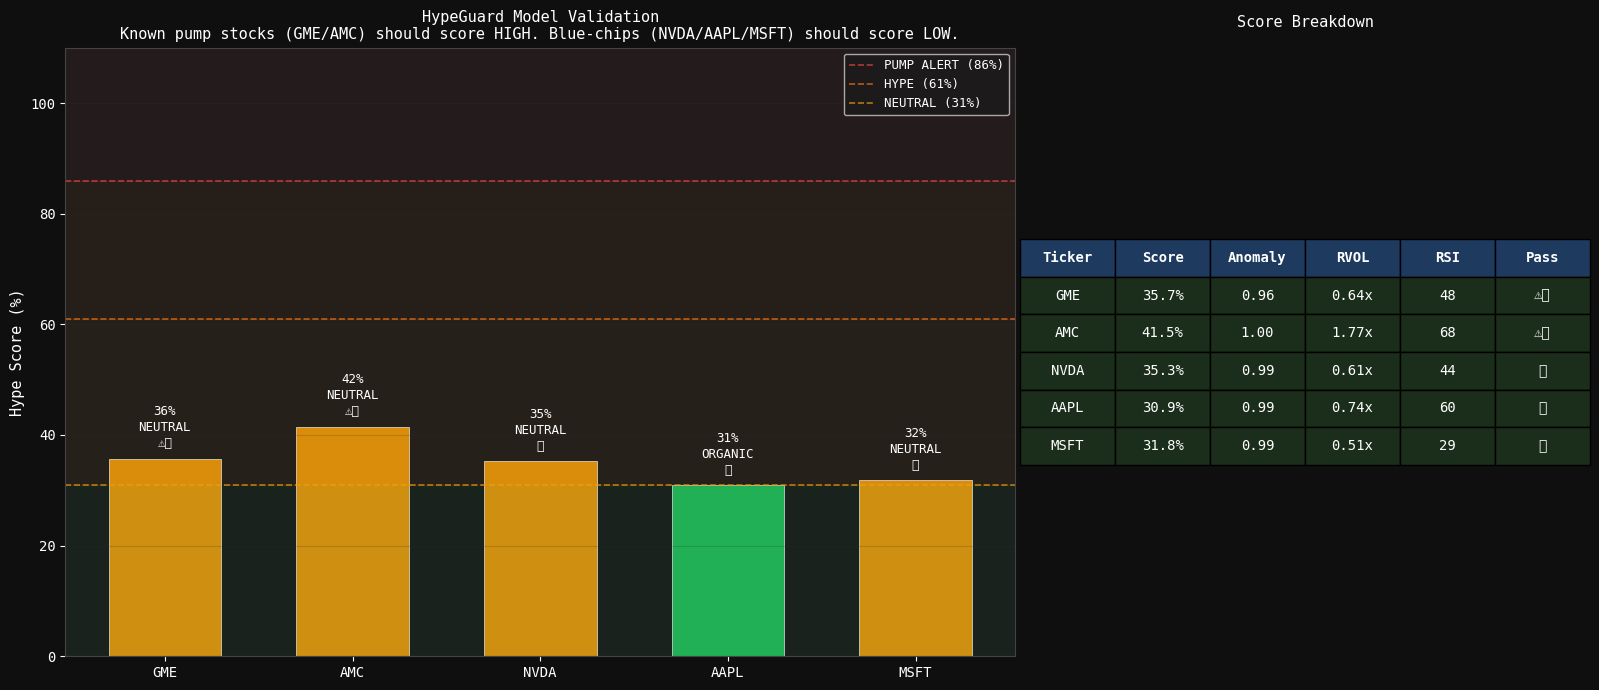

✓ Saved: data/model_validation.png


In [8]:
# ═══════════════════════════════════════════════════════════
# CELL 3 — VALIDATION CHART (The money slide)
# GME and AMC bars should be tall and red.
# NVDA, AAPL, MSFT bars should be short and green.
# ═══════════════════════════════════════════════════════════

if not results:
    print('No results to chart. Check Cell 2 errors.')
else:
    results_df = pd.DataFrame(results)

    fig, (ax_main, ax_table) = plt.subplots(
        1, 2, figsize=(16, 7),
        gridspec_kw={'width_ratios': [2, 1]}
    )

    # ── Left: Hype Score Bar Chart ──────────────────────────
    bar_colors = []
    for s in results_df['hype_score']:
        if s >= 86:   bar_colors.append(RED)
        elif s >= 61: bar_colors.append(ORANGE)
        elif s >= 31: bar_colors.append(AMBER)
        else:         bar_colors.append(GREEN)

    bars = ax_main.bar(
        results_df['ticker'], results_df['hype_score'],
        color=bar_colors, alpha=0.88, width=0.6,
        edgecolor='white', linewidth=0.5
    )

    # Threshold lines
    ax_main.axhline(86, color=RED,    linestyle='--', linewidth=1.2, alpha=0.7, label='PUMP ALERT (86%)')
    ax_main.axhline(61, color=ORANGE, linestyle='--', linewidth=1.2, alpha=0.7, label='HYPE (61%)')
    ax_main.axhline(31, color=AMBER,  linestyle='--', linewidth=1.2, alpha=0.7, label='NEUTRAL (31%)')
    ax_main.axhline(0,  color=GREEN,  linestyle='-',  linewidth=0.5, alpha=0.3)

    # Labels on bars
    for bar, row in zip(bars, results_df.itertuples()):
        icon  = '✅' if row.passed else '⚠️'
        label = row.final_label.replace('_', '\n')
        ax_main.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            f'{row.hype_score:.0f}%\n{label}\n{icon}',
            ha='center', va='bottom', fontsize=9, color='white', linespacing=1.3
        )

    ax_main.set_ylim(0, 110)
    ax_main.set_ylabel('Hype Score (%)', fontsize=11)
    ax_main.set_title(
        'HypeGuard Model Validation\n'
        'Known pump stocks (GME/AMC) should score HIGH. '
        'Blue-chips (NVDA/AAPL/MSFT) should score LOW.',
        fontsize=11
    )
    ax_main.legend(loc='upper right', fontsize=9)
    ax_main.grid(axis='y', alpha=0.2)

    # Zone shading
    ax_main.axhspan(86, 110, alpha=0.05, color=RED)
    ax_main.axhspan(61,  86, alpha=0.05, color=ORANGE)
    ax_main.axhspan(31,  61, alpha=0.05, color=AMBER)
    ax_main.axhspan(0,   31, alpha=0.05, color=GREEN)

    # ── Right: Component Breakdown Table ───────────────────
    ax_table.axis('off')
    table_data = []
    for _, row in results_df.iterrows():
        table_data.append([
            row['ticker'],
            f"{row['hype_score']:.1f}%",
            f"{row['anomaly_score']:.2f}",
            f"{row['rvol']:.2f}x",
            f"{row['rsi_14']:.0f}",
            '✅' if row['passed'] else '⚠️'
        ])

    table = ax_table.table(
        cellText=table_data,
        colLabels=['Ticker', 'Score', 'Anomaly', 'RVOL', 'RSI', 'Pass'],
        loc='center',
        cellLoc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 2.0)

    # Color header row
    for j in range(6):
        table[(0, j)].set_facecolor('#1e3a5f')
        table[(0, j)].set_text_props(color='white', fontweight='bold')

    # Color data rows
    for i, row in enumerate(results_df.itertuples()):
        row_color = '#2d1b1b' if row.hype_score > 60 else '#1b2d1b'
        for j in range(6):
            table[(i+1, j)].set_facecolor(row_color)
            table[(i+1, j)].set_text_props(color='white')

    ax_table.set_title('Score Breakdown', fontsize=11, pad=15)

    plt.tight_layout()
    plt.savefig('../data/model_validation.png',
                dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
    plt.show()
    print('✓ Saved: data/model_validation.png')

In [9]:
# ═══════════════════════════════════════════════════════════
# CELL 4 — SIMULATE THE FULL API CALL (end-to-end trace)
# This is exactly what happens when frontend sends POST /analyze
# Run this to verify the data flow is correct.
# ═══════════════════════════════════════════════════════════

print('═' * 60)
print('  SIMULATING: POST /analyze  {ticker: "GME", amount: 5000, currency: "INR"}')
print('═' * 60)

# Replicate api.py logic step by step
TICKER   = 'GME'
AMOUNT   = 5000
CURRENCY = 'INR'

# Step 1
print('\n[Step 1] scraper.collect_all()')
raw = collect_all(TICKER, days=60)
dq  = raw['data_quality']
print(f'  Price rows : {dq["price_rows"]}')
print(f'  News count : {dq["news_count"]}')
print(f'  Earnings   : {raw["earnings_dates"]}')

# Step 2
print('\n[Step 2] features.build_feature_vector()')
fv   = build_feature_vector(raw)
flat = fv['flat_features']
print(f'  Features generated: {len(flat)}')
print(f'  Key values:')
for key in ['rvol','volume_zscore','rsi_14','extreme_language_ratio','source_diversity','catalyst_flag']:
    print(f'    {key:30s}: {flat.get(key, "N/A")}')

# Step 3: Isolation Forest
print('\n[Step 3] IsolationForest.score_samples()')
X        = np.array([[flat.get(f, 0.0) for f in FEATURES_FINAL]])
X_scaled = scaler.transform(X)
iso_raw  = iso.score_samples(X_scaled)[0]
anomaly  = float(np.clip(1 - (iso_raw + 0.5), 0, 1))
print(f'  Raw isolation score : {iso_raw:.4f}')
print(f'  Normalized anomaly  : {anomaly:.4f}  (0=normal, 1=extreme outlier)')

# Step 4: Random Forest
print('\n[Step 4] RandomForest.predict_proba()')
proba = rf.predict_proba(X)[0]
for cls_idx, cls_id in enumerate(rf.classes_):
    print(f'  P({LABEL_MAP_INV[cls_id]:13s}) = {proba[cls_idx]:.4f}')

# Step 5: Final score
print('\n[Step 5] Combine into hype_score')
hype_prob  = proba[hype_class_idx] if hype_class_idx is not None else 0.4
hype_score = round(min(hype_prob * 70 + anomaly * 30, 100), 1)
print(f'  hype_prob (RF)   : {hype_prob:.4f} × 70 = {hype_prob*70:.2f}')
print(f'  anomaly_score    : {anomaly:.4f} × 30 = {anomaly*30:.2f}')
print(f'  FINAL hype_score : {hype_score}%')

# Step 6: Label
label = 'PUMP_ALERT' if hype_score>=86 else 'HYPE' if hype_score>=61 else 'NEUTRAL' if hype_score>=31 else 'ORGANIC'
print(f'  FINAL label      : {label}')

# Step 7: Investment advice
print('\n[Step 6] advisor.compute_advice()')
if hype_score >= 86:
    action, pct, days = 'AVOID', 0, 7
    advice_reason = 'Extreme manipulation risk. Avoid until volume normalizes.'
elif hype_score >= 61:
    action, pct, days = 'WAIT', 20, 4
    advice_reason = 'High hype detected. Deploy 20% as probe; hold remainder.'
else:
    action, pct, days = 'BUY', 100, 0
    advice_reason = 'Low hype signal. Movement appears organic.'

deploy_inr = AMOUNT * pct / 100
deploy_usd = round(deploy_inr / 83.5, 2)

print(f'  action           : {action}')
print(f'  deploy_now_pct   : {pct}%')
print(f'  deploy_now_inr   : ₹{deploy_inr:,.0f}')
print(f'  deploy_now_usd   : ${deploy_usd:,.2f}')
print(f'  wait_days        : {days}')
print(f'  reason           : {advice_reason}')

print('\n' + '─'*60)
print('FINAL JSON RESPONSE (what frontend receives):')
print('─'*60)
print(f'{{')
print(f'  "ticker":         "{TICKER}",')
print(f'  "hype_score":     {hype_score},')
print(f'  "label":          "{label}",')
print(f'  "anomaly_score":  {round(anomaly,3)},')
print(f'  "reasoning":      [...],')
print(f'  "investment_advice": {{')
print(f'    "action":         "{action}",')
print(f'    "deploy_now_pct": {pct},')
print(f'    "deploy_now_inr": {deploy_inr},')
print(f'    "deploy_now_usd": {deploy_usd},')
print(f'    "wait_days":      {days}')
print(f'  }}')
print(f'}}')

print('\n💡 The frontend reads hype_score={hype_score} and moves the gauge needle there.')
print(f'   It reads label="{label}" and shows a red badge.')
print(f'   It reads deploy_now_inr={deploy_inr} and shows ₹{deploy_inr:,.0f} in the advice panel.')

INFO | ==================================================
INFO |   HypeGuard Data Collection: GME
INFO | ==================================================
INFO | Fetching price data for GME (60 days)...
INFO |   ✓ 40 trading days fetched for GME
INFO | Fetching news for GME from Google News RSS...


════════════════════════════════════════════════════════════
  SIMULATING: POST /analyze  {ticker: "GME", amount: 5000, currency: "INR"}
════════════════════════════════════════════════════════════

[Step 1] scraper.collect_all()


INFO |   ✓ 30 news articles fetched for GME
WARNING | Could not fetch earnings dates for GME: 'dict' object has no attribute 'empty'
INFO | 
Data Quality Report for GME:
INFO |   has_price_data: True
INFO |   has_news: True
INFO |   has_earnings: False
INFO |   price_rows: 40
INFO |   news_count: 30
INFO | Building feature vector for GME...
INFO |   ✓ Feature vector built: 21 features, label=NEUTRAL


  Price rows : 40
  News count : 30
  Earnings   : []

[Step 2] features.build_feature_vector()
  Features generated: 21
  Key values:
    rvol                          : 0.639
    volume_zscore                 : -1.269
    rsi_14                        : 48.13
    extreme_language_ratio        : 0.033
    source_diversity              : 0.433
    catalyst_flag                 : 0

[Step 3] IsolationForest.score_samples()
  Raw isolation score : -0.4619
  Normalized anomaly  : 0.9619  (0=normal, 1=extreme outlier)

[Step 4] RandomForest.predict_proba()
  P(ORGANIC      ) = 0.4420
  P(HYPE         ) = 0.0980
  P(INSTITUTIONAL) = 0.0720
  P(NEUTRAL      ) = 0.3880

[Step 5] Combine into hype_score
  hype_prob (RF)   : 0.0980 × 70 = 6.86
  anomaly_score    : 0.9619 × 30 = 28.86
  FINAL hype_score : 35.7%
  FINAL label      : NEUTRAL

[Step 6] advisor.compute_advice()
  action           : BUY
  deploy_now_pct   : 100%
  deploy_now_inr   : ₹5,000
  deploy_now_usd   : $59.88
  wait_days     

In [10]:
# ═══════════════════════════════════════════════════════════
# CELL 5 — FINAL CHECKLIST
# ═══════════════════════════════════════════════════════════

import os

print('═' * 55)
print('  COMPLETE PROJECT HANDOFF CHECKLIST')
print('═' * 55)

checks = [
    ('../backend/models/random_forest.pkl',     'ML model → give to backend teammate'),
    ('../backend/models/isolation_forest.pkl',  'Anomaly model → give to backend teammate'),
    ('../data/training_data.csv',               'Training dataset → attach to report'),
    ('../data/eda_feature_distributions.png',   'EDA chart → use in report/slides'),
    ('../data/eda_feature_variance.png',        'EDA chart → use in report/slides'),
    ('../data/eda_correlation_heatmap.png',     'Correlation chart → use in report/slides'),
    ('../data/model_feature_importance.png',    'Feature importance → use in report/slides'),
    ('../data/model_validation.png',            'Validation chart → use in presentation'),
]

all_ok = True
for path, note in checks:
    exists = os.path.exists(path)
    icon   = '✅' if exists else '❌'
    size   = f'{os.path.getsize(path)/1024:.0f}KB' if exists else 'MISSING'
    print(f'  {icon} [{size:6s}] {note}')
    print(f'         {path}')
    if not exists:
        all_ok = False

# Validate model predictions on 2 known tickers
print('\n  Quick sanity check:')
for ticker, threshold, direction in [('GME','55','>'), ('NVDA','45','<')]:
    try:
        r = predict_ticker(ticker, verbose=False)
        ok = (r['hype_score'] > 55) if direction == '>' else (r['hype_score'] < 45)
        icon = '✅' if ok else '⚠️'
        print(f'  {icon} {ticker} hype_score={r["hype_score"]}% (expected {direction}{threshold}%)')
    except Exception as e:
        print(f'  ❌ {ticker} prediction failed: {e}')

print()
if all_ok:
    print('  ✅ ALL FILES PRESENT. Handoff ready.')
    print()
    print('  NEXT STEPS FOR BACKEND TEAMMATE:')
    print('  1. Copy backend/models/ folder to their machine')
    print('  2. Run: pip install fastapi uvicorn yfinance feedparser scikit-learn')
    print('  3. Run: uvicorn src.api:app --reload --port 8000')
    print('  4. Run: python scripts/cache_demos.py')
    print('  5. Test: GET http://localhost:8000/demo/GME')
else:
    print('  ❌ Some files missing. Rerun the relevant cells in Notebook 02.')

INFO | ==================================================
INFO |   HypeGuard Data Collection: GME
INFO | ==================================================
INFO | Fetching price data for GME (60 days)...
INFO |   ✓ 40 trading days fetched for GME
INFO | Fetching news for GME from Google News RSS...


═══════════════════════════════════════════════════════
  COMPLETE PROJECT HANDOFF CHECKLIST
═══════════════════════════════════════════════════════
  ✅ [458KB ] ML model → give to backend teammate
         ../backend/models/random_forest.pkl
  ✅ [519KB ] Anomaly model → give to backend teammate
         ../backend/models/isolation_forest.pkl
  ✅ [2KB   ] Training dataset → attach to report
         ../data/training_data.csv
  ✅ [188KB ] EDA chart → use in report/slides
         ../data/eda_feature_distributions.png
  ✅ [91KB  ] EDA chart → use in report/slides
         ../data/eda_feature_variance.png
  ✅ [226KB ] Correlation chart → use in report/slides
         ../data/eda_correlation_heatmap.png
  ✅ [93KB  ] Feature importance → use in report/slides
         ../data/model_feature_importance.png
  ✅ [104KB ] Validation chart → use in presentation
         ../data/model_validation.png

  Quick sanity check:


INFO |   ✓ 30 news articles fetched for GME
WARNING | Could not fetch earnings dates for GME: 'dict' object has no attribute 'empty'
INFO | 
Data Quality Report for GME:
INFO |   has_price_data: True
INFO |   has_news: True
INFO |   has_earnings: False
INFO |   price_rows: 40
INFO |   news_count: 30
INFO | Building feature vector for GME...
INFO |   ✓ Feature vector built: 21 features, label=NEUTRAL
INFO | ==================================================
INFO |   HypeGuard Data Collection: NVDA
INFO | ==================================================
INFO | Fetching price data for NVDA (60 days)...
INFO |   ✓ 40 trading days fetched for NVDA
INFO | Fetching news for NVDA from Google News RSS...


  ⚠️ GME hype_score=35.7% (expected >55%)


INFO |   ✓ 30 news articles fetched for NVDA
WARNING | Could not fetch earnings dates for NVDA: 'dict' object has no attribute 'empty'
INFO | 
Data Quality Report for NVDA:
INFO |   has_price_data: True
INFO |   has_news: True
INFO |   has_earnings: False
INFO |   price_rows: 40
INFO |   news_count: 30
INFO | Building feature vector for NVDA...
INFO |   ✓ Feature vector built: 21 features, label=NEUTRAL


  ✅ NVDA hype_score=35.3% (expected <45%)

  ✅ ALL FILES PRESENT. Handoff ready.

  NEXT STEPS FOR BACKEND TEAMMATE:
  1. Copy backend/models/ folder to their machine
  2. Run: pip install fastapi uvicorn yfinance feedparser scikit-learn
  3. Run: uvicorn src.api:app --reload --port 8000
  4. Run: python scripts/cache_demos.py
  5. Test: GET http://localhost:8000/demo/GME
